In [29]:
import os
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [31]:
DATASET_PATH = "/kaggle/input/datasets/niranjankn/esc50/ESC-50-master"

AUDIO_PATH = os.path.join(DATASET_PATH, "audio")
META_PATH = os.path.join(DATASET_PATH, "meta", "esc50.csv")

df = pd.read_csv(META_PATH)

print(df.shape)

df.head()

(2000, 7)


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [32]:
print(f"Total audio files: {len(df)}")

print(f"Number of classes: {df['category'].nunique()}")

print("\nClasses:\n")
print(sorted(df["category"].unique()))

Total audio files: 2000
Number of classes: 50

Classes:

['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks', 'door_wood_knock', 'drinking_sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'hand_saw', 'helicopter', 'hen', 'insects', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind']


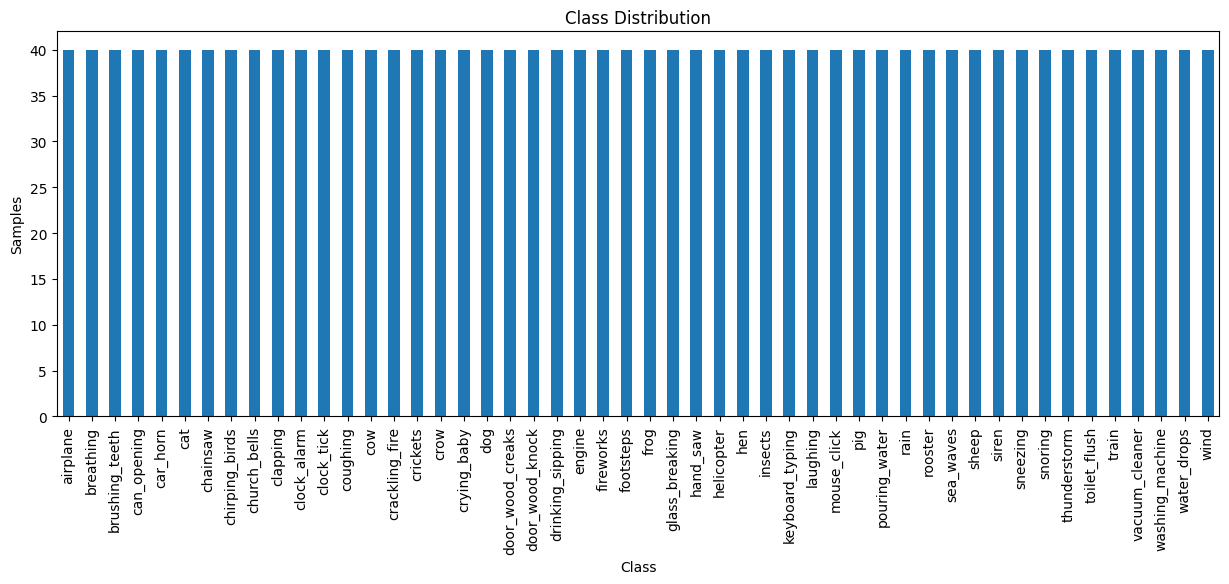

In [33]:
plt.figure(figsize=(15,5))

df["category"].value_counts().sort_index().plot(kind="bar")

plt.title("Class Distribution")

plt.xlabel("Class")

plt.ylabel("Samples")

plt.xticks(rotation=90)

plt.show()

In [34]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["category"])

NUM_CLASSES = len(label_encoder.classes_)

print("Number of classes:", NUM_CLASSES)

df[["category", "label"]].head()

Number of classes: 50


,category,label
0,dog,18
1,chirping_birds,7
2,vacuum_cleaner,46
3,vacuum_cleaner,46
4,thunderstorm,43


In [35]:
sample = df.sample(1, random_state=SEED).iloc[0]

audio_path = os.path.join(AUDIO_PATH, sample.filename)

signal, sr = librosa.load(audio_path, sr=16000)

print("Category:", sample.category)

print("Sample Rate:", sr)

print("Duration:", len(signal)/sr, "seconds")

Category: clapping
Sample Rate: 16000
Duration: 5.0 seconds


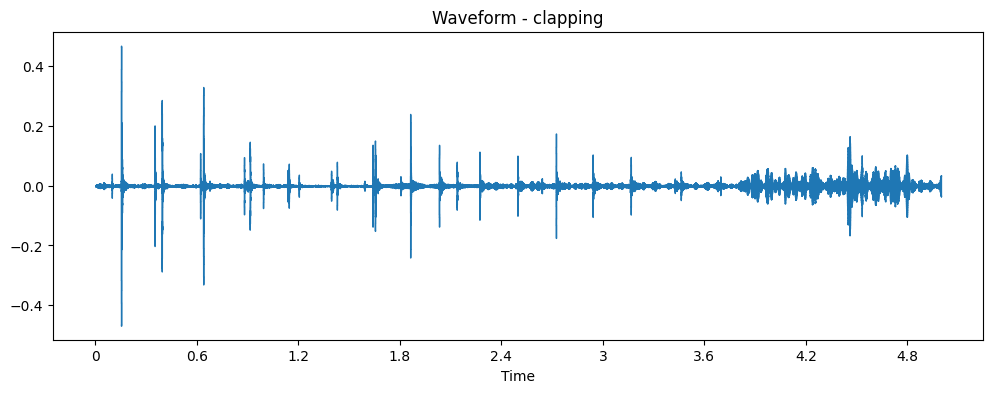

In [36]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(signal, sr=sr)

plt.title(f"Waveform - {sample.category}")

plt.show()

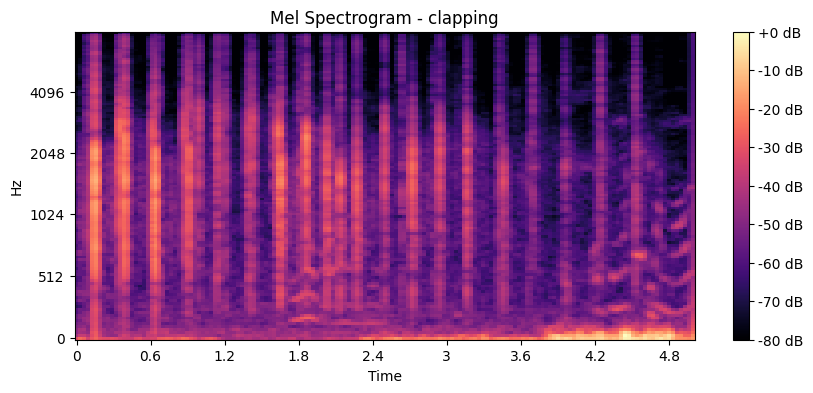

In [37]:
mel = librosa.feature.melspectrogram(
    y=signal,
    sr=sr,
    n_mels=128,
    n_fft=2048,
    hop_length=512
)

mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel",
    cmap="magma"
)

plt.colorbar(format="%+2.0f dB")

plt.title(f"Mel Spectrogram - {sample.category}")

plt.show()

In [38]:
train_df = df[df["fold"].isin([1, 2, 3])].reset_index(drop=True)

val_df = df[df["fold"] == 4].reset_index(drop=True)

test_df = df[df["fold"] == 5].reset_index(drop=True)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 1200
Validation: 400
Testing: 400


In [39]:
SAMPLE_RATE = 16000
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

In [40]:
def extract_features(audio_path):
    signal, sr = librosa.load(audio_path, sr=SAMPLE_RATE)

    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Standardize
    mel_db = (mel_db - np.mean(mel_db)) / (np.std(mel_db) + 1e-8)

    return mel_db.astype(np.float32)

(128, 157)


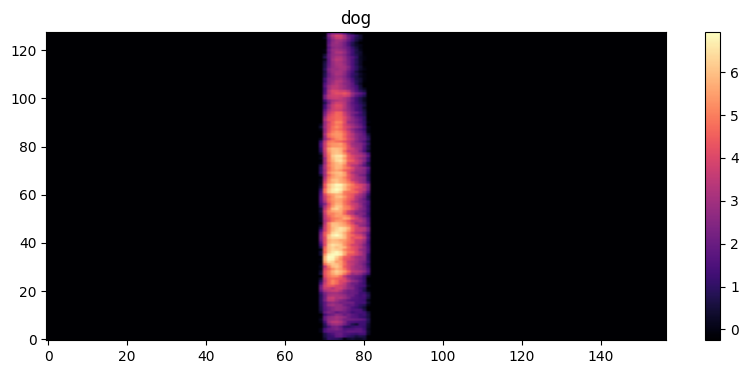

In [41]:
sample_path = os.path.join(
    AUDIO_PATH,
    train_df.iloc[0]["filename"]
)

feature = extract_features(sample_path)

print(feature.shape)

plt.figure(figsize=(10,4))

plt.imshow(
    feature,
    origin="lower",
    aspect="auto",
    cmap="magma"
)

plt.colorbar()

plt.title(train_df.iloc[0]["category"])

plt.show()

In [42]:
def build_dataset(dataframe):
    X = []
    y = []

    for _, row in dataframe.iterrows():

        path = os.path.join(AUDIO_PATH, row["filename"])

        feature = extract_features(path)

        X.append(feature)
        y.append(row["label"])

    return np.array(X), np.array(y)

In [43]:
X_train, y_train = build_dataset(train_df)
X_val, y_val = build_dataset(val_df)
X_test, y_test = build_dataset(test_df)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1200, 128, 157)
(400, 128, 157)
(400, 128, 157)


In [44]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (1200, 128, 157, 1)
Validation: (400, 128, 157, 1)
Testing: (400, 128, 157, 1)


In [45]:
NUM_CLASSES = len(label_encoder.classes_)

y_train = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print(y_train.shape)

(1200, 50)


In [46]:
def residual_block(inputs, filters):

    x = layers.Conv2D(filters, (3,3), padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)

    # Shortcut connection
    shortcut = inputs

    if inputs.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding="same")(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

In [47]:
inputs = layers.Input(shape=X_train.shape[1:])

# Block 1
x = layers.Conv2D(32, (3,3), padding="same")(inputs)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D((2,2))(x)

# Block 2
x = residual_block(x, 64)
x = layers.MaxPooling2D((2,2))(x)

# Block 3
x = residual_block(x, 128)
x = layers.MaxPooling2D((2,2))(x)

# Block 4
x = residual_block(x, 256)
x = layers.MaxPooling2D((2,2))(x)

# Classification Head
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 157,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 157,  │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 157,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 157,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 78,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 78,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 78,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 64, 78,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 78,    │     36,928 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 78,    │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 78,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 78,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 78,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 78,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 39,    │          0 │ re_lu_2[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 39,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 39,    │        512 │ conv2d_4[0][0]  

 Total params: 1,290,034 (4.92 MB)

 Trainable params: 1,287,282 (4.91 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [48]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

In [49]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),

    ModelCheckpoint(
        "best_esc50_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )

]

In [50]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=50,

    batch_size=32,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0302 - loss: 4.5538
Epoch 1: val_accuracy improved from None to 0.02000, saving model to best_esc50_model.keras

Epoch 1: finished saving model to best_esc50_model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.0350 - loss: 4.2145 - val_accuracy: 0.0200 - val_loss: 3.9080 - learning_rate: 3.0000e-04
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0703 - loss: 3.7696
Epoch 2: val_accuracy improved from 0.02000 to 0.02750, saving model to best_esc50_model.keras

Epoch 2: finished saving model to best_esc50_model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.0825 - loss: 3.6908 - val_accuracy: 0.0275 - val_loss: 3.9662 - learning_rate: 3.0000e-04
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1187 - loss: 3.5233
Epoch 3: val_accuracy did not improve from 0.02750
38/38 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.1308 - loss: 3.4806 - val_accuracy: 0.0200 - val_loss: 4.0

In [51]:
from tensorflow.keras.models import load_model

best_model = load_model("best_esc50_model.keras")

In [52]:
test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 388ms/step - accuracy: 0.6600 - loss: 1.8086

Test Accuracy: 0.6600
Test Loss: 1.8086


In [53]:
predictions = best_model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 410ms/step


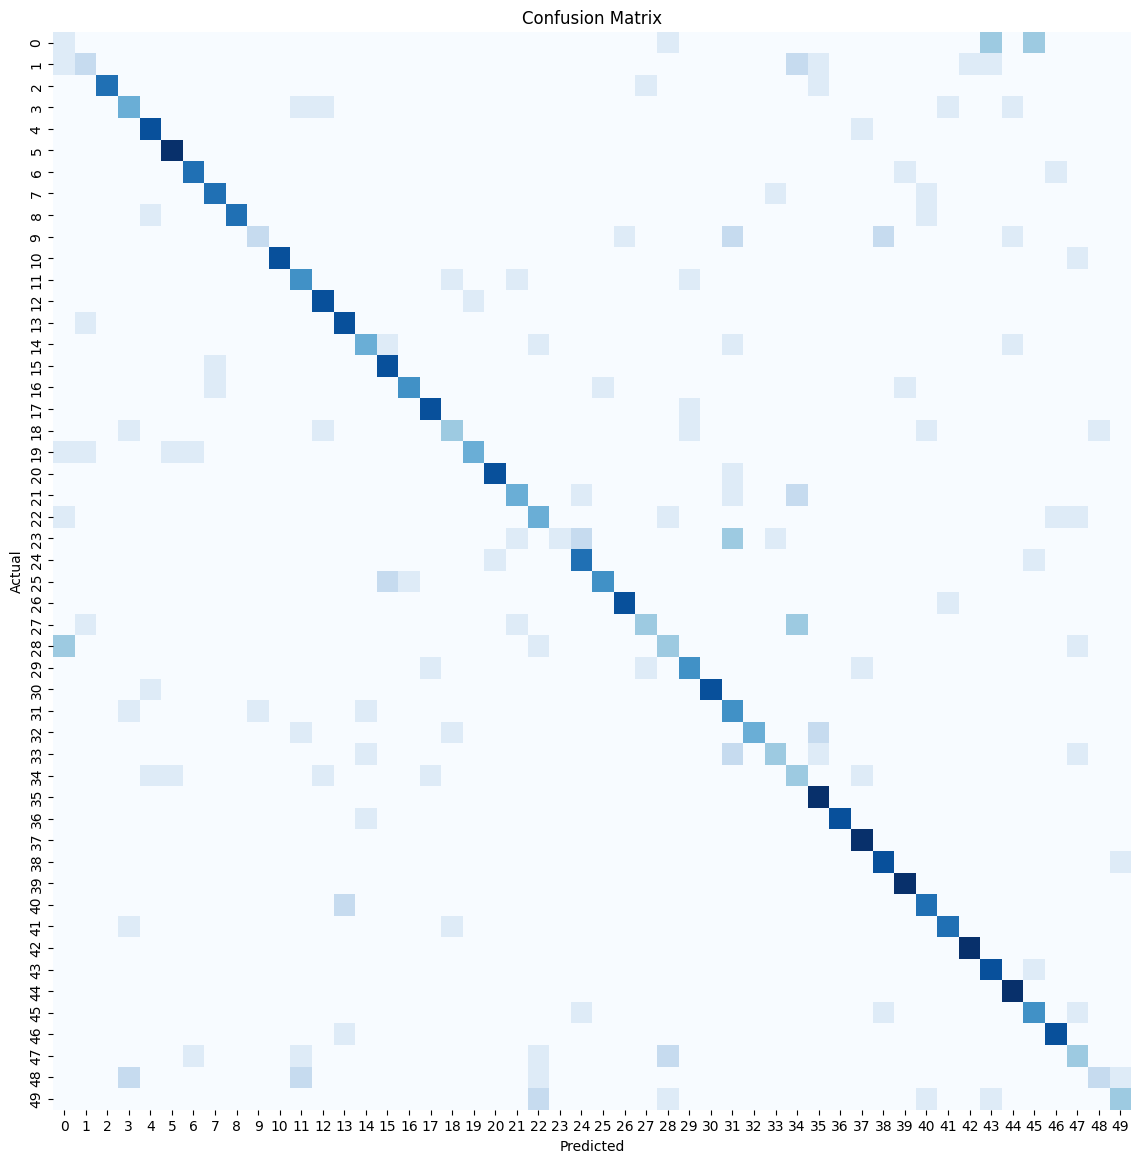

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14,14))

sns.heatmap(
    cm,
    cmap="Blues",
    square=True,
    cbar=False
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [55]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

                  precision    recall  f1-score   support

        airplane       0.14      0.12      0.13         8
       breathing       0.40      0.25      0.31         8
  brushing_teeth       1.00      0.75      0.86         8
     can_opening       0.44      0.50      0.47         8
        car_horn       0.70      0.88      0.78         8
             cat       0.80      1.00      0.89         8
        chainsaw       0.75      0.75      0.75         8
  chirping_birds       0.75      0.75      0.75         8
    church_bells       1.00      0.75      0.86         8
        clapping       0.67      0.25      0.36         8
     clock_alarm       1.00      0.88      0.93         8
      clock_tick       0.50      0.62      0.56         8
        coughing       0.70      0.88      0.78         8
             cow       0.70      0.88      0.78         8
  crackling_fire       0.57      0.50      0.53         8
        crickets       0.70      0.88      0.78         8
            c

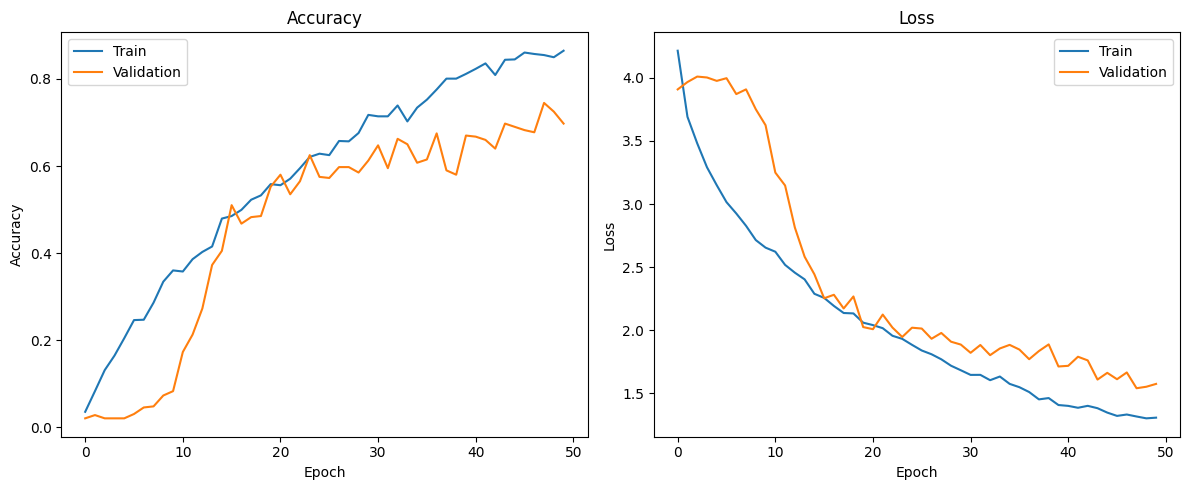

In [56]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.tight_layout()

plt.show()

In [58]:
best_model.save("/kaggle/working/esc50_sound_classifier.keras")

In [59]:
sample_path = os.path.join(
    AUDIO_PATH,
    test_df.iloc[10]["filename"]
)

feature = extract_features(sample_path)

feature = feature[np.newaxis, ..., np.newaxis]

prediction = best_model.predict(feature)

predicted_class = label_encoder.inverse_transform(
    [np.argmax(prediction)]
)[0]

confidence = np.max(prediction)

print("Predicted:", predicted_class)
print(f"Confidence: {confidence:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted: wind
Confidence: 46.68%
